# Quick Start Guide

This notebook provides an end-to-end walkthrough of the BioNeuralNet pipeline using a synthetic demo dataset, following the stages of the [Data Decision Framework](https://bioneuralnet.readthedocs.io/en/latest/data_decision_framework.html):

- Network construction
- Network quality assessment
- Phenotype-driven subgraph detection
- Downstream disease prediction via Graph Neural Networks

## Load Demo Dataset

BioNeuralNet includes built-in demo datasets via ``DatasetLoader``, allowing you to explore the full framework without preparing your own data.

- Two omics layers: 500 genes and 100 miRNAs
- 358 pre-aligned samples with phenotype and clinical annotations

In [ ]:
#!pip install bioneuralnet
#!pip install torch
#!pip install torch_geometric

In [1]:
import pandas as pd
from bioneuralnet.datasets import DatasetLoader

Example = DatasetLoader("example")
omics1 = Example.data["X1"]
omics2= Example.data["X2"]
phenotype = Example.data["Y"]
clinical = Example.data["clinical"]

In [2]:
# Inspect the first 3 rows and 5 colums.

display(omics1.iloc[:3,:5])
display(omics1.shape)

display(omics2.iloc[:3,:5])
display(omics2.shape)

display(clinical.iloc[:3,:5])
display(clinical.shape)

display(phenotype.iloc[:3,:5])
display(phenotype.shape)

,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5
Samp_1,22.485701,40.353720,31.025745,20.847206,26.697293
Samp_2,37.058850,34.052233,33.487020,23.531461,26.754628
Samp_3,20.530767,31.669623,35.189567,20.952544,25.018826


(358, 500)

,Mir_1,Mir_2,Mir_3,Mir_4,Mir_5
Samp_1,15.223913,17.545826,15.784719,14.891983,10.348205
Samp_2,16.306965,16.672830,13.361529,14.488549,12.660905
Samp_3,16.545119,16.735005,14.617472,17.845267,13.822790


(358, 100)

,Age,Gender,BMI,Chronic_Bronchitis,Emphysema
PatientID,,,,,
Samp_1,78,0,31.2,1,1
Samp_2,68,1,19.2,1,0
Samp_3,54,1,19.3,0,1


(358, 6)

,phenotype
Samp_1,235.067423
Samp_2,253.544991
Samp_3,234.204994


(358, 1)

## Constructing a Multi-omics Network

BioNeuralNet supports a variety of graph construction techniques to model relationships between biological features. These graphs serve as the foundation for applying Graph Neural Networks in downstream tasks. Using the following functions, users can convert a multi-omics dataset (subjects in rows, features in columns) into a weighted adjacency matrix suitable for GNN-based analysis.

We recommend building 3-5 candidate networks and evaluating each with the ``NetworkAnalyzer`` class before selecting one for downstream modeling. See the [Data Decision Framework](https://bioneuralnet.readthedocs.io/en/latest/data_decision_framework.html) for guidance on parameter selection and topology assessment.

Supported graph construction methods:

- **Similarity** - cosine or Euclidean similarity with optional k-NN sparsification
- **Correlation** - Pearson or Spearman correlation mapped to [0,1]
- **Threshold** - soft-thresholding on absolute Pearson correlation (WGCNA-style)
- **Gaussian k-NN** - Gaussian (RBF) kernel on Euclidean distances
- **Phenotype-driven (SmCCNet)** - supervised multi-omics network inference via the native ``auto_pysmccnet`` integration

Each method is available through the `bioneuralnet.network` module. Additional details and examples can be found in the [Network Construction documentation](https://bioneuralnet.readthedocs.io/en/latest/utils.html).

## Example 1: SmCCNet 2.0

SmCCNet 2.0 is a phenotype-driven network inference method based on Sparse Multiple Canonical Correlation Analysis (SmCCA), constructing multi-omics networks specific to a variable of interest (e.g., a disease phenotype).

It is available via `from bioneuralnet.network import auto_pysmccnet`. R and the SmCCNet R package are required. For setup instructions see the [Network Construction documentation](https://bioneuralnet.readthedocs.io/en/latest/utils.html).

**Resources**

- CRAN: [SmCCNet on CRAN](https://cran.r-project.org/web/packages/SmCCNet/)
- GitHub: [KechrisLab/SmCCNet](https://github.com/KechrisLab/SmCCNet)
- Paper: [Liu et al., BMC Bioinformatics (2024)](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/s12859-024-05900-9)

In [3]:
from bioneuralnet.network import auto_pysmccnet
from bioneuralnet.utils import set_seed

SEED = 123
set_seed(SEED)

result = auto_pysmccnet(
    X=[omics1, omics2],
    Y=phenotype,
    DataType=["genes", "mirna"],
    subSampNum=1000,
    seed=SEED,
    Kfold=3,
    BetweenShrinkage=5,
    CutHeight=1 - 0.1**10,
    summarization="NetSHy",
)

global_network = result["AdjacencyMatrix"]
subnetworks = result["Subnetworks"]

Setting global seed for reproducibility to: 123
CUDA available. Applying seed to all GPU operations
Seed setting complete




**********************************
* Welcome to Automated SmCCNet! *
* Device: cpu
**********************************


This project uses multiomics CCA


--------------------------------------------------
>> Determining scaling factor...
--------------------------------------------------

The scaling factor selection is: 

genes-mirna: 0.07357254609375365
genes-Phenotype: 1.0
mirna-Phenotype: 1.0

--------------------------------------------------
>> Determining best penalty via Cross-Validation...
--------------------------------------------------

>> Generating random K-Fold splits...
Processing fold 1/3...
Processing fold 2/3...
Processing fold 3/3...


The best penalty term for genes is: 0.1
The best penalty term for mirna is: 0.1
Testing Canonical Correlation: 1.696, Prediction Error: 0.037

Running multi-omics CCA with best penalty on complete dataset.



Robust Weights: 100%|██████████| 1000/1000 [00:25<00:00, 38.96it/s]



--------------------------------------------------
>> Now starting network clustering...
--------------------------------------------------

Clustering completed...

--------------------------------------------------
>> Now starting network pruning and summarization score extraction...
--------------------------------------------------


There are 6 network modules before pruning
 Now extracting subnetwork for network module 1
Network module 1 Result:The final network size is: 19 with maximum PC correlation w.r.t. phenotype to be: 0.679
 Now extracting subnetwork for network module 2
Network module 2 Result:The final network size is: 21 with maximum PC correlation w.r.t. phenotype to be: 0.090

************************************
* Execution Finished!            *
************************************



In [4]:
print(f"Global network shape: {global_network.shape}")
print(f"Number of SmCCnet clusters: {len(subnetworks)}")

print(subnetworks[1].keys())

Global network shape: (600, 600)
Number of SmCCnet clusters: 2
dict_keys(['module_id', 'nodes', 'node_indices', 'adjacency', 'correlation', 'pc_correlations', 'netshy', 'omics_correlation'])


## Network Quality Assessment

Before proceeding to GNN embedding, we use the ``NetworkAnalyzer`` class to inspect the topology of both the global network and the strongest subnetwork (Module 1, PC correlation: 0.679). This corresponds to the Network Quality stage of the Data Decision Framework.

- **Density and isolated nodes** confirm the network is suitable for stable GNN message passing.
- **Hub analysis** identifies the most highly connected molecular features driving the subnetwork structure.
- **Cross-omics connectivity** reveals whether network structure is driven by within-omics or between-omics interactions.

For a full parameter reference and topology interpretation guide, see the [Data Decision Framework](https://bioneuralnet.readthedocs.io/en/latest/data_decision_framework.html).

In [5]:
from bioneuralnet.network import NetworkAnalyzer

global_analyzer = NetworkAnalyzer(adjacency_matrix=global_network)
global_analyzer.edge_weight_analysis()
global_analyzer.basic_statistics(threshold=0.001)
global_analyzer.cross_omics_analysis(threshold=0.001)
_ = global_analyzer.find_strongest_edges(top_n=10)

module_analyzer = NetworkAnalyzer(adjacency_matrix=subnetworks[1]["adjacency"])
module_analyzer.edge_weight_analysis()
module_analyzer.basic_statistics(threshold=0.001)
module_analyzer.hub_analysis(threshold=0.001, top_n=10)
module_analyzer.cross_omics_analysis(threshold=0.001)
_ = module_analyzer.find_strongest_edges(top_n=5)

Initialized on CUDA
Nodes: 600
Omics types: ['genes', 'mirna']

EDGE WEIGHT DISTRIBUTION
Total edges (weight > 0): 1,395
Weight statistics:
 Mean: 0.004743
 Std: 0.046160
 Median: 0.000013
 Min: 0.000000
 Max: 1.000000

Percentiles:
  25th: 0.000001
  50th: 0.000013
  75th: 0.000122
  90th: 0.001690
  95th: 0.009074
  99th: 0.063821

Edges at different biological thresholds:
  > 0.001: 192 edges
  > 0.1: 10 edges
  > 0.3: 5 edges
  > 0.5: 3 edges
  > 0.7: 2 edges
  > 0.8: 2 edges
  > 0.9: 2 edges

BASIC NETWORK STATISTICS (threshold > 0.001)
Nodes: 600
Edges: 192
Density: 0.001068
Avg Degree: 0.64
Max Degree: 32
Min Degree: 0
Isolated Nodes: 564 (94.0%)

CROSS-OMICS CONNECTIVITY (threshold > 0.001)

Omics Pair           |      Edges | Max Possible |    Density
------------------------------------------------------------
genes (within)       |        136 |      124,750 |   0.001090
genes-mirna          |         56 |       50,000 |   0.001120
mirna (within)       |          0 |        4

In [ ]:
# smccnet prefixes the network: the following lines remove this prefix to allow dpmon and hybrid louvain to match on omics/nodes
# ONLY need to run this two lines once

global_network.index = global_network.index.str.split('_', n=1).str[1]
global_network.columns = global_network.columns.str.split('_', n=1).str[1]

## Phenotype-Driven Subgraph Detection

The ``NetworkAnalyzer`` results reveal a sparse global network (density: 0.001, 192 edges) with strong cross-omics interactions concentrated around a small set of hub features. To systematically identify the biologically meaningful subgraphs driving phenotype association within this structure, we apply the ``HybridLouvain`` module.

``HybridLouvain`` alternates between Correlated Louvain community detection and Correlated PageRank refinement to isolate subgraphs that simultaneously maximize phenotype correlation and internal connectivity. Detecting significant subgraphs within multi-omics networks can help identify complex biological relationships involved in disease progression (Abdel-Hafiz et al., 2022).

Key parameters and their trade-offs:

- **`k_L`**: controls the balance between modularity and phenotype correlation in the Louvain objective. Lower values (e.g., 0.2) emphasize correlation; higher values (e.g., 0.8) favor well-connected communities but may reduce phenotype relevance.
- **`teleport_prob`**: higher values restrict PageRank to nodes near the seed set, producing smaller and more focused subgraphs; lower values allow broader exploration of the network.
- **`k_P`**: controls the balance between conductance and correlation in the PageRank sweep cut. Lower values prioritize phenotype signal over topological compactness.
- **`max_iter`**: correlation generally peaks at iterations 3–5 before declining as the subgraph becomes over-restricted.

In [14]:
from bioneuralnet.clustering import HybridLouvain
omics_combined = pd.concat([omics1, omics2], axis=1)

hl = HybridLouvain(
    G=global_network,
    B=omics_combined,
    Y=phenotype,
    k_L=0.7,
    k_P=0.8,
    max_iter=10,
    min_nodes=5,
    seed=123,
)
subnetworks_hl = hl.run(as_dfs=True)

Converting adjacency DataFrame to NetworkX graph.
HybridLouvain: nodes=600, edges=1395, features=600, k_L=0.7, teleport=0.05, k_P=0.8, max_iter=10

--- Iteration 1: 600 nodes remaining ---
CorrelatedLouvain: n=600, k_L=0.7, matched_features=600/600
Level 1: 600 nodes
Level 2: 571 nodes
Correlated Louvain done: 571 communities, Q=-0.1574, Q*=-0.0554
Top community: |rho|=0.4729, size=2
CorrelatedPageRank: nodes=600, teleport=0.05 (nx_alpha=0.95), k_P=0.8
Personalization: 2 nodes, max_weight=0.0500, min_weight=0.0500
PageRank computation completed.
Sweep cut: size=42, cond=0.6221, corr=0.5752, composite=0.3826
  Iteration 0: 42 nodes, |rho|=0.5752

--- Iteration 2: 42 nodes remaining ---
CorrelatedLouvain: n=42, k_L=0.7, matched_features=42/42
Level 1: 42 nodes
Level 2: 20 nodes
Correlated Louvain done: 20 communities, Q=0.0001, Q*=0.0472
Top community: |rho|=0.5893, size=2
CorrelatedPageRank: nodes=42, teleport=0.05 (nx_alpha=0.95), k_P=0.8
Personalization: 2 nodes, max_weight=0.0500, mi

## Subgraph Visualization

We visualize the detected subgraphs using ``plot_network``, which renders the weighted adjacency structure and returns a ranked node mapping table. Key parameters:

- **`weight_threshold`**: filters edges below this value; adjust based on the network's weight distribution to balance visual clarity against information loss.
- **`show_labels`**: displays numeric node indices, mapped to feature names in the returned DataFrame.
- **`show_edge_weights`**: annotates edges with their raw adjacency weights.
- **`layout`**: graph layout algorithm; `"kamada"` (default) works well for sparse biological networks, `"spring"` and `"spectral"` are available for denser structures.

Node size scales with degree, making hub features visually prominent. The summary box reports full cluster size before and after threshold filtering.

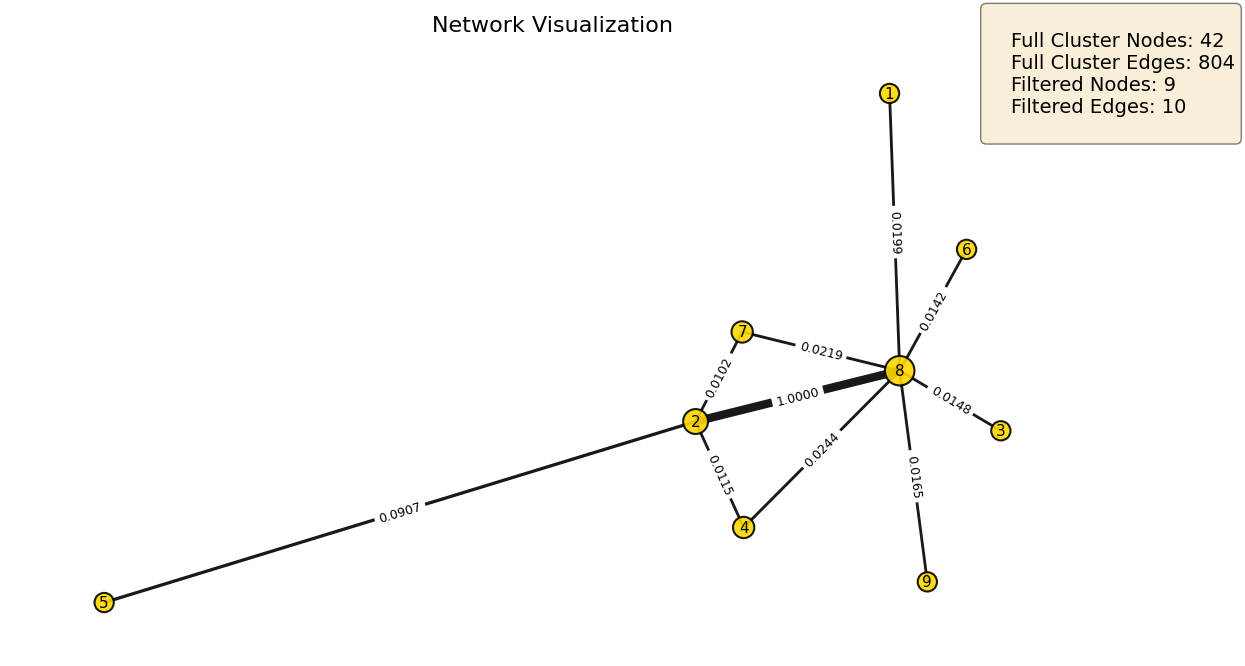

           Omic  Degree
Index                  
8         Mir_2       7
2        Gene_7       4
4       Gene_28       2
7      Gene_485       2
1      Gene_222       1
3       Gene_46       1
5        Mir_53       1
6      Gene_214       1
9      Gene_219       1


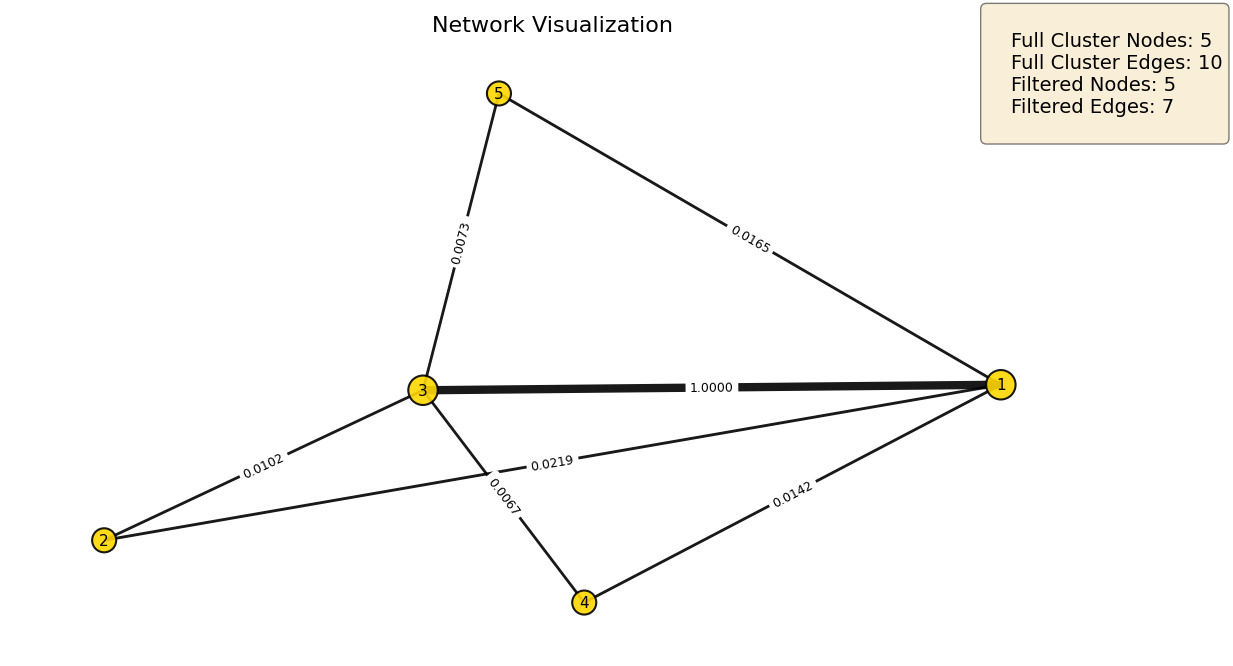

           Omic  Degree
Index                  
1         Mir_2       4
3        Gene_7       4
2      Gene_485       2
4      Gene_214       2
5      Gene_219       2


In [35]:
from bioneuralnet.metrics import plot_network

# Iteration 0: 42 nodes, |rho| = 0.575
iteration0 = subnetworks_hl[0]

mapping_0 = plot_network(
    iteration0,
    weight_threshold=0.01,
    show_labels=True,
    show_edge_weights=True
)
print(mapping_0.head(10))

# Iteration 1: 5 nodes, |rho| = 0.513
iteration1 = subnetworks_hl[1]

mapping_1 = plot_network(
    iteration1,
    weight_threshold=0.001,
    show_labels=True,
    show_edge_weights=True
)
print(mapping_1.head(10))

## Disease Classification with DPMON

DPMON enables end-to-end network-based phenotype prediction by integrating omics data, clinical variables, and network structure within a single pipeline. It combines the adjacency network from the previous step with multi-omics data and optional clinical covariates, supporting GCN, GAT, GraphSAGE, and GIN architectures.

In this example, we binarize the continuous phenotype using a median split, enabling binary classification.

In [37]:
from bioneuralnet.datasets import DatasetLoader
import pandas as pd

Example = DatasetLoader("example")
omics1 = Example.data["X1"]
omics2 = Example.data["X2"]
phenotype = Example.data["Y"]
clinical = Example.data["clinical"]

phenotype["phenotype"] = (phenotype["phenotype"] > phenotype["phenotype"].median()).astype(int)

print(phenotype)
print(phenotype["phenotype"].value_counts(sort=False))

          phenotype
Samp_1            0
Samp_2            1
Samp_3            0
Samp_4            1
Samp_5            1
...             ...
Samp_354          0
Samp_355          0
Samp_356          1
Samp_357          0
Samp_358          0

[358 rows x 1 columns]
phenotype
0    179
1    179
Name: count, dtype: int64


## DPMON: End-to-End Disease Prediction

DPMON (Disease Prediction using Multi-Omics Networks) integrates omics data, clinical variables, and network structure into a single end-to-end supervised pipeline. While the module offers extensive configurability, BioNeuralNet is designed to eliminate manual guesswork. Setting `tune=True` activates automated hyperparameter optimization across an empirically validated search space covering GNN depth, hidden dimensions, learning rate, weight decay, and autoencoder encoding dimension.

Here we run DPMON on the global SmCCNet network (600 nodes), enabling the full embedding space to be projected for latent space visualization and omics modality separation analysis.

- `cv=True` enables stratified K-fold cross-validation (`n_folds=5`)
- `tune=True` searches the validated parameter space across `tune_trials=20` configurations
- `.run()` returns predictions, evaluation metrics, and learned embeddings

For a full parameter reference, see the [DPMON API documentation](https://bioneuralnet.readthedocs.io/en/latest/user_api.html).

In [43]:
from bioneuralnet.downstream_task import DPMON

dpmon = DPMON(
    adjacency_matrix=global_network,
    omics_list=[omics1, omics2],
    phenotype_data=phenotype,
    phenotype_col="phenotype",
    clinical_data=clinical,
    cv=True,
    tune=True,
    n_folds=5,
    repeat_num=1,
    output_dir="dpmon_output"
)

predictions, metrics, embeddings = dpmon.run()

Output directory set to: dpmon_output
Initialized DPMON with model: GAT
Setting global seed for reproducibility to: 1804
CUDA available. Applying seed to all GPU operations
Seed setting complete
Random seed set to: 1804
Running in Cross-Validation mode (cv=True) with 5 folds.
CV Setup: Standard 5-fold split.
Starting Fold 1/5
Building graph with 600 common features.
Node feature matrix shape: (600, 6) (mode=abs_pearson)
Inner CV: 5 folds  |  X shape: (286, 600)  |  Graph nodes: torch.Size([600, 6])
Best trial config: {'gnn_layer_num': 3, 'gnn_hidden_dim': 64, 'lr': 0.00040867069309739006, 'weight_decay': 0.002578131912470874, 'nn_hidden_dim1': 256, 'nn_hidden_dim2': 64, 'ae_encoding_dim': 4, 'ae_architecture': 'original', 'num_epochs': 256, 'gnn_dropout': 0.5, 'gnn_activation': 'relu', 'dim_reduction': 'ae', 'gat_heads': 1}
Best trial val_accuracy: 0.8495
Best trial val_loss: 0.3716
Best trial val_f1_macro: 0.8485
Best trial val_aupr: 0.9328
Fold 1 best config: {'gnn_layer_num': 3, 'gn

## Latent Space Visualization

We project the feature embeddings learned by DPMON into a 2D latent space using t-SNE. This allows inspection of how different omics layers cluster within the learned representation and whether the GNN has captured meaningful separation between modalities. Node labels map each feature to its source omics layer.

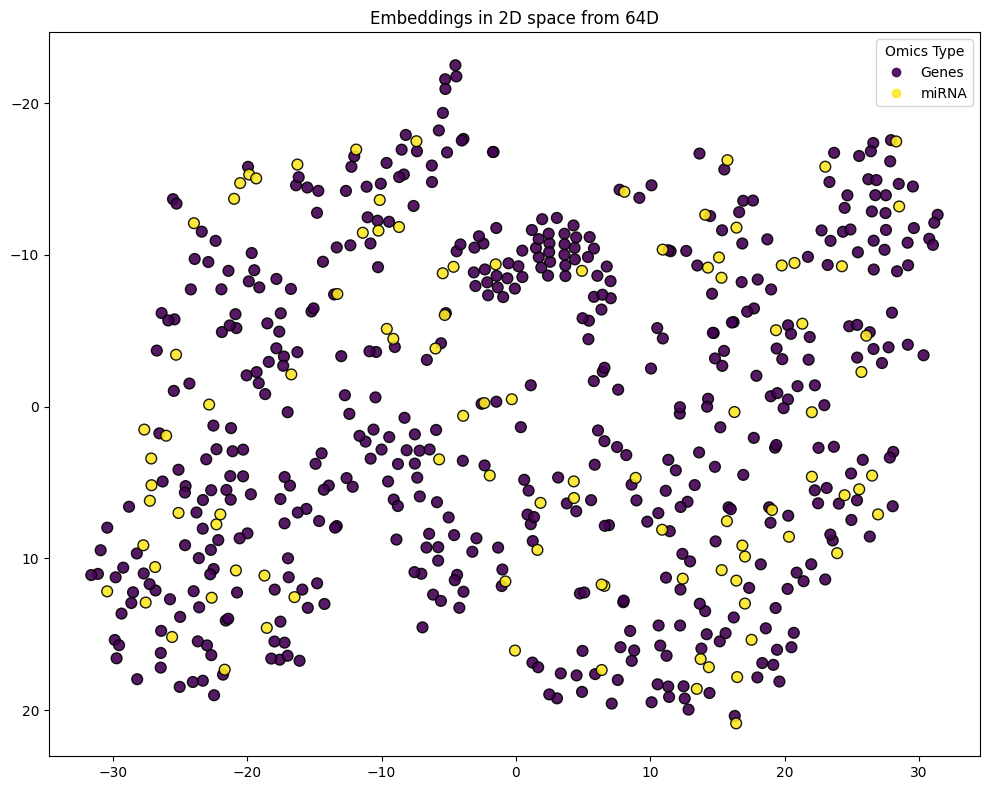

In [44]:
import numpy as np
from bioneuralnet.metrics import plot_embeddings
feature_names = global_network.index.tolist()
embeddings_df = pd.DataFrame(embeddings.numpy(), index=feature_names)

node_labels = []
gene_feats = set(omics1.columns)
mirna_feats = set(omics2.columns)

for feat in feature_names:
    if feat in gene_feats:
        node_labels.append(1)
    elif feat in mirna_feats:
        node_labels.append(2)
    else:
        node_labels.append(0)

node_labels = np.array(node_labels)

plot_embeddings(
    embeddings=embeddings_df,
    node_labels=node_labels,
    legend_labels=["Genes", "miRNA"]
)


## Summary

This notebook demonstrated the complete BioNeuralNet workflow on a synthetic multi-omics dataset:

- Network construction via SmCCNet
- Topology assessment with ``NetworkAnalyzer``
- Phenotype-driven subgraph detection with ``HybridLouvain``
- End-to-end binary classification with DPMON (Avg AUC: 0.924)

For a full API reference, see the [Documentation](https://bioneuralnet.readthedocs.io/en/latest/user_api.html).